# Setup — the fixed phenomenological model

Companion to [`setup_model_phenomenological.ipynb`](setup_model_phenomenological.ipynb), which draws a
fresh random event on every call, and to [`setup_model.ipynb`](setup_model.ipynb), which standardises
the five catO5 files. This notebook builds **one fixed jet** from the same Nava (2020) / Abe et al.
(2026) recipe, with every input at the population's central value. The same call always returns the
same $L(E', t'; \theta_v)$. It is tabulated once on a 1° grid in $\theta_v$ and saved in the
`GRBModelSet` `.npz` format of the catO5 cache, so `sim_3d` can load either one the same way.

The code is in [`gwuls/grb_phenomenological.py`](../gwuls/grb_phenomenological.py), section
"A fixed (deterministic) jet":

| | |
| --- | --- |
| `JetParams`, `BENCHMARK` | One frozen parameter set. `BENCHMARK` holds the population medians. |
| `offaxis_luminosity`, `model_at_theta`, `model_set` | The off-axis element integral of Abe et al. (2026) Sec. 3.4, after Lamb & Kobayashi (2017). It replaces the local closure of the stochastic notebook, which is clipped at $\theta_\mathrm{max}$ (40° for this jet). |
| `one_sigma_variants`, `draw_jet_params` | The two ways to put the population scatter back in, when it is wanted (§5). |

**Why a fixed model loses little.** In every iteration the model is rescaled to the trial luminosity
$L_k$ over the GTIs (guidelines Step 6), so anything that only multiplies $L$ drops out of the upper
limit. That removes the largest random terms of the recipe: the $L_X$–$E_\mathrm{iso}$ scatter
(0.5 dex), the $L_\mathrm{TeV}/L_X$ scatter (0.3 dex) and the amplitude part of $E_{\gamma,\mathrm{iso}}$.
What is left are the few inputs that change the *shape* of the model: $\theta_\mathrm{core}$,
$\Gamma_\mathrm{core}$, the time scale set by $E_{\gamma,\mathrm{iso}}$, $\beta_2$ and the photon
index. §5 measures how much each one moves the model, and how to carry them into the simulation.

**Contents.** 1. The benchmark jet · 2. The off-axis element integral · 3. The benchmark at every
angle · 4. Cross-check against the catO5 files · 5. Putting the scatter back · 6. Saving the cache ·
7. How `sim_3d` uses it · 8. Caveats

In [1]:
import sys
sys.path.insert(0, "..")

import time
import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
from dataclasses import replace

import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
from matplotlib.colors import LinearSegmentedColormap, Normalize
from scipy.integrate import quad
from scipy.optimize import brentq

from gwuls import angle_distribution, grb_model, paths
from gwuls import grb_phenomenological as ph

paths.ensure_dirs()
plt.rcParams["figure.dpi"] = 100

FIT_CATO5 = True        # §4: fit theta_core, Gamma_core to each catO5 file (~2 min)
SAVE_VARIANTS = False   # §6: also write the ten one-sigma variant caches (~10 min)

theta_cmap = LinearSegmentedColormap.from_list("theta", ["#86b6ef", "#3987e5", "#184f95", "#0d366b"])
theta_norm = Normalize(0, 90)


def vhe_lum(model, t):
    # 0.3-1 TeV luminosity of a GRBModel at rest-frame times t, erg/s (the band of the 11 h anchor)
    E = np.geomspace(*ph.VHE_BAND_GEV, 50)
    return np.trapezoid(model.at(E, t) * E[:, None] ** 2, np.log(E), axis=0) * u.GeV.to(u.erg)

## 1. The benchmark jet

Every input is the median of its population distribution in Nava (2020) and Abe et al. (2026).
The last column says whether the input can reach an upper limit on $L_k$ at all.

| input | benchmark | population | reaches the $L_k$ limit? |
| --- | --- | --- | --- |
| $E_{\gamma,\mathrm{iso}}$ | $2.0\times10^{50}$ erg | $E_\mathrm{peak}$ broken power law, then Amati (Ghirlanda et al. 2016) | only through the time scale, $t\propto E^{1/3}$ |
| $\theta_\mathrm{core}$ | 14.1° | lognormal, $\log_{10}$ mean 1.15, σ 0.2 dex (Fong et al. 2015) | yes |
| $\Gamma_\mathrm{core}$ | 200 | lognormal, $\log_{10}$ mean 2.3, σ 0.2 dex | yes, near the axis |
| $\beta_1$ (rise) | 2 | normal, σ 0.05 | negligibly |
| $\beta_2$ (decay) | −1.45 | normal, σ 0.48 (22 short GRBs) | yes |
| photon index $p$ | 2.2 | normal, σ 0.1 | yes |
| $L_\mathrm{TeV,11h}$ | mean relations: $L_X$ from Berger (2014), $L_\mathrm{TeV}/L_X=1$ | 0.5 dex and 0.3 dex lognormal scatter | no, amplitude only |
| $n$, $\eta_\gamma$ | 0.1 cm⁻³, 0.2 | fixed in both sources | — |

The median $E_{\gamma,\mathrm{iso}}$ depends on the lower cut of the $E_\mathrm{peak}$ distribution
(`EPEAK_MIN_KEV`). It is recomputed below, with the 16th/84th percentiles that
`one_sigma_variants` uses.

In [2]:
B = ph.BENCHMARK
print(B)
print(f"\nE_k,iso (core)          = {B.ek_iso_core_erg:.2e} erg")
print(f"t_dec (core, rest frame) = {B.t_dec_core_s:.1f} s")
print(f"L_TeV,11h (0.3-1 TeV)    = {B.l_tev_11h_erg_s:.2e} erg/s")
print(f"theta_max (Gamma_0 = 5)  = {ph.theta_max_deg(B.theta_core_deg, B.gamma_core):.1f} deg")

e_pop = ph.epeak_to_egiso_erg(ph.draw_epeak_keV(np.random.default_rng(20260929), 400_000))
print(f"\npopulation E_gamma,iso 16/50/84% = {np.percentile(e_pop, [16, 50, 84])} erg")

JetParams(e_gamma_iso_erg=2e+50, theta_core_deg=14.12537544622754, gamma_core=199.52623149688787, beta1=2.0, beta2=-1.45, photon_index=2.2, ltev_11h_erg_s=None, n_cm3=0.1, eta_gamma=0.2)

E_k,iso (core)          = 8.00e+50 erg
t_dec (core, rest frame) = 14.9 s
L_TeV,11h (0.3-1 TeV)    = 2.23e+43 erg/s
theta_max (Gamma_0 = 5)  = 39.5 deg

population E_gamma,iso 16/50/84% = [3.53972549e+48 2.01963413e+50 2.04222224e+51] erg


## 2. The off-axis element integral

Each element of the jet, at angle $\theta$ from its axis, is a small blast wave with isotropic-equivalent
energy $E_{k,\mathrm{iso}}\,\varepsilon(\theta)$ and Lorentz factor $\Gamma_0(\theta)$ (Abe et al. Eqs. 1–2).
Seen along its own velocity it shows the recipe's light curve, with its own deceleration time:

$$
h(\theta, t) = \varepsilon(\theta)\left(\frac{t}{11\,\mathrm h}\right)^{\beta_2}\ \ (t \ge t_\mathrm{dec}(\theta)),
\qquad h \propto t^{\beta_1}\ \ (t < t_\mathrm{dec}(\theta)),
\qquad
\Gamma(t) = \Gamma_0(\theta)\,\min\!\left(1, (t/t_\mathrm{dec})^{-3/8}\right).
$$

After the peak every element decays like the core, scaled by its energy (at fixed time, a decelerating
blast wave has forgotten $\Gamma_0$). An observer at angle $\alpha$ from the element's velocity sees
it Doppler-shifted by $a = \delta(\alpha)/\delta(0) = (1-\beta)/(1-\beta\cos\alpha)$:

$$
L_\mathrm{obs}(t_\mathrm{obs}) = \sum_\text{elements} \frac{d\Omega}{\Omega_\mathrm{beam}(\Gamma)}\; a^{2+p}\; h(\theta, t),
\qquad \frac{dt_\mathrm{obs}}{dt} = \frac{1}{a}.
$$

- $a^{2+p}$: a power law $dN/dE\propto E^{-p}$ stays a power law under a Doppler shift, so the
  luminosity at fixed energy scales as $a^{2+p}$ and **the spectrum never changes shape off-axis**.
- $\Omega_\mathrm{beam}(\Gamma) = \int a^{2+p}\,d\Omega$: the solid angle a uniform shell beams into.
  With it, a spherical shell of uniform $\Gamma$ reproduces its own on-axis light curve for any observer.
- The time mapping is integrated, since $\Gamma$ and so $a$ change during the emission.

The grid is centred on the line of sight: $\alpha$ log-spaced from $10^{-5}$ rad to π (it resolves the
beaming cone $\alpha\sim1/\Gamma$ at every Γ), azimuth ψ uniform. Elements past $\theta_\mathrm{max}$
($\Gamma_0<5$) are left out, as in Abe et al. Sec. 3.1.

**Energy convention.** $t_\mathrm{dec}$ uses the *isotropic-equivalent* kinetic energy,
$E_{\gamma,\mathrm{iso}}(1-\eta_\gamma)/\eta_\gamma$, since before it spreads each part of the jet
decelerates like a sphere of its own isotropic energy. `sample_events` (stochastic notebook) passes
the collimated $E_k$ instead, which puts $t_\mathrm{dec}$ about 5× earlier for $\theta_\mathrm{core}=14°$.
§4 supports the isotropic choice: the 9.1° catO5 file peaks at 3 s. With its $E_\mathrm{iso}$ and the
benchmark core, $t_\mathrm{dec}$ is 4.4 s with the isotropic energy and 1.1 s with the collimated one.

### 2.1 Check: on-axis, against an independent 1-D calculation

A near-uniform jet ($\theta_\mathrm{core}\to500°$, so $\varepsilon\approx1$ and $\Gamma_0\approx\Gamma_\mathrm{core}$
across the whole beaming cone), seen on-axis. In the small-angle limit $dt_\mathrm{obs}/dt = 1+\Gamma^2\alpha^2$,
so every $\alpha$ can be solved exactly for its emission time, one angle at a time, with no grid in
time or azimuth. The 2-D element integral must agree with that.

The same limit gives closed forms for how the arrival-time spread across the beaming cone rescales each
power-law segment (with $q=2+p$, $x=\Gamma^2\alpha^2$). Before $t_\mathrm{dec}$ the factor is
$(q-1)/(q+\beta_1-1)$. Long after it, the factor is $(q-1)\int_0^\infty(1+x)^{1-q}(1+4x)^{-1-\beta_2}dx$,
where the 4 comes from $\Gamma\propto t^{-3/8}$. Even on-axis, the integral therefore returns the input
light curve times a factor that differs between the rise and the decay. `model_at_theta` normalises
that away at the 11 h anchor (§3).

element integral vs 1-D calculation, 0.3 s - 1e6 s: max |d log10 L| = 0.0018
closed-form factors: rise 0.615, decay (t >> t_dec) 2.508


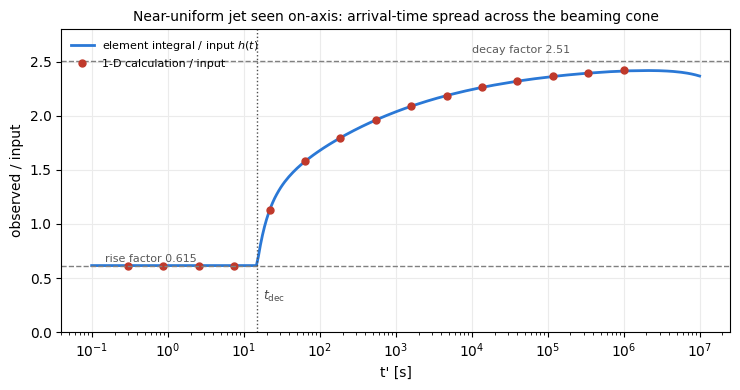

In [3]:
U = replace(B, theta_core_deg=500.0)
G0, td, q, T = U.gamma_core, U.t_dec_core_s, 2 + U.photon_index, ph.T_ANCHOR_S


def h(t):   # the element's own on-axis light curve, in units of its 11 h value
    return (t / T) ** U.beta2 if t >= td else (td / T) ** U.beta2 * (t / td) ** U.beta1


def gamma2(t):
    return G0 ** 2 if t < td else G0 ** 2 * (t / td) ** -0.75


def t_obs_of(t, al):   # int_0^t (1 + Gamma^2 alpha^2) dt'
    if t < td:
        return t * (1 + G0 ** 2 * al ** 2)
    return t + al ** 2 * (G0 ** 2 * td + 4 * G0 ** 2 * td ** 0.75 * (t ** 0.25 - td ** 0.25))


def L_1d(to):   # dOmega / Omega_beam = (q-1) Gamma^2 d(alpha^2) at Gamma >> 1
    al = np.geomspace(1e-6, 0.5, 2000)
    t_em = np.array([brentq(lambda t: t_obs_of(t, a) - to, 1e-12, to) for a in al])
    g2 = np.array([gamma2(t) for t in t_em])
    hh = np.array([h(t) for t in t_em])
    return np.trapezoid(2 * al * (q - 1) * g2 * (1 + g2 * al ** 2) ** -q * hh, al)


t_chk = np.geomspace(0.3, 1e6, 15)
L_ref = np.array([L_1d(t) for t in t_chk])
L_2d = ph.offaxis_luminosity(U, 0.0, t_chk)
print(f"element integral vs 1-D calculation, 0.3 s - 1e6 s: "
      f"max |d log10 L| = {np.max(np.abs(np.log10(L_2d / L_ref))):.4f}")

rise = (q - 1) / (q + U.beta1 - 1)
decay = (q - 1) * quad(lambda x: (1 + x) ** (1 - q) * (1 + 4 * x) ** (-1 - U.beta2), 0, np.inf)[0]
print(f"closed-form factors: rise {rise:.3f}, decay (t >> t_dec) {decay:.3f}")

t_plot = np.geomspace(0.1, 1e7, 300)
ratio = ph.offaxis_luminosity(U, 0.0, t_plot) / np.array([h(t) for t in t_plot])
fig, ax = plt.subplots(figsize=(7.5, 4))
ax.semilogx(t_plot, ratio, color="#2a78d6", lw=2, label="element integral / input $h(t)$")
ax.semilogx(t_chk, L_ref / np.array([h(t) for t in t_chk]), "o", ms=5, color="#c0392b",
            label="1-D calculation / input")
ax.axhline(rise, color="0.5", ls="--", lw=1)
ax.axhline(decay, color="0.5", ls="--", lw=1)
ax.text(0.15, rise * 1.06, f"rise factor {rise:.3f}", fontsize=8, color="0.35")
ax.text(2e5, decay * 1.03, f"decay factor {decay:.2f}", fontsize=8, color="0.35", ha="right")
ax.axvline(td, color="0.3", ls=":", lw=1)
ax.text(td * 1.2, 0.3, "$t_{\\rm dec}$", fontsize=9, color="0.3")
ax.set_ylim(0, 2.8)
ax.set_xlabel("t' [s]"); ax.set_ylabel("observed / input")
ax.set_title("Near-uniform jet seen on-axis: arrival-time spread across the beaming cone", fontsize=10)
ax.grid(True, which="major", color="0.92", lw=0.8)
ax.legend(fontsize=8, frameon=False, loc="upper left")
fig.tight_layout()
plt.show()

The decay factor approaches its asymptote only as $t^{-1/4}$, because the pre-deceleration part of
$\int\Gamma^2dt$ fades slowly. That is physics, and the 1-D calculation, which uses the same exact
$t_\mathrm{obs}(t)$, follows the element integral all the way.

### 2.2 Check: grid convergence

The default grid (240 α × 128 ψ × 24 points per decade in time) against one twice as fine in all three.

In [4]:
t_out = np.geomspace(1e-1, 1e7, 161)
fine = dict(n_alpha=480, n_psi=256, t_on_s=np.geomspace(1e-4, 1e9, 13 * 48 + 1))
print(f"{'theta_v [deg]':>13} {'time [s]':>9} {'max |d log10 L| vs 2x finer':>28}")
for th in [0, 5, 14, 30, 45, 60, 80]:
    t0 = time.time()
    L_default = ph.offaxis_luminosity(B, th, t_out)
    dt = time.time() - t0
    L_fine = ph.offaxis_luminosity(B, th, t_out, **fine)
    print(f"{th:13d} {dt:9.2f} {np.max(np.abs(np.log10(L_default / L_fine))):28.4f}")

theta_v [deg]  time [s]  max |d log10 L| vs 2x finer
            0      0.01                       0.0026
            5      0.74                       0.0074
           14      0.72                       0.0037
           30      0.69                       0.0033
           45      0.06                       0.0023
           60      0.02                       0.0074
           80      0.02                       0.0200


## 3. The benchmark at every angle

`model_set` builds the model on `DEFAULT_THETA_GRID_DEG` (0°, 1°, …, 90°). Each angle is normalised
by the same constant, so the on-axis 0.3–1 TeV luminosity at $t'=11$ h is exactly
$L_\mathrm{TeV,11h}$. The ratio between angles is the element integral's.

The orange curve on the right is the local closure of the stochastic notebook (`grb_model_at_theta`),
which assigns the viewer the $t_\mathrm{dec}$ of the element on the line of sight. It is recomputed
here with the same isotropic energy, so the only difference left is the physics. Past $\theta_\mathrm{max}$
the local closure has nothing on the line of sight and is frozen. The shaded curve is the $\theta_v$
distribution cached for S240615dg by `setup_angle_distribution.ipynb`, to show where this alert's
draws fall.

91 angles built in 29 s
on-axis 0.3-1 TeV luminosity at 11 h / L_TeV,11h = 1.000013


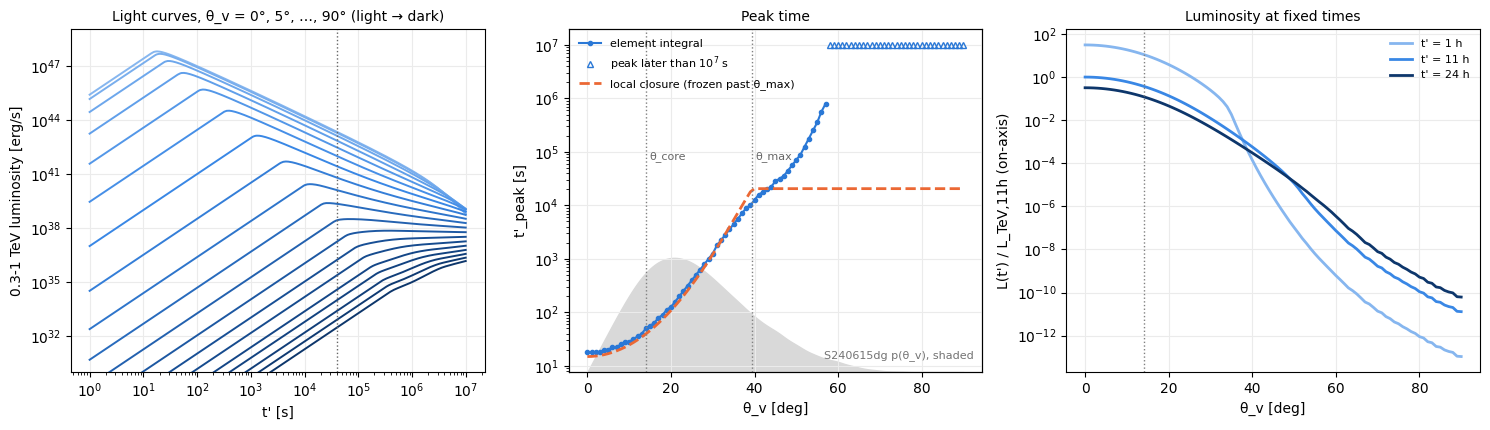

 theta_v  t_peak [s]  L(11h)/L_TeV,11h
       0        17.8          1.00e+00
      10        28.2          6.05e-01
      14        50.1          3.74e-01
      20         126          1.36e-01
      25         398          4.50e-02
      30    1.26e+03          1.22e-02
      35    4.47e+03          2.83e-03
      40    1.26e+04          5.76e-04
      45    2.82e+04          9.92e-05
      50    7.08e+04          1.20e-05
      60        >1e7          7.49e-08
      75        >1e7          4.35e-10
      90        >1e7          1.30e-11


In [5]:
t0 = time.time()
bench = ph.model_set(B)
print(f"{len(bench.models)} angles built in {time.time() - t0:.0f} s")
thetas = bench.angles_deg
on_axis_anchor = vhe_lum(bench.models[0.0], np.array([ph.T_ANCHOR_S]))[0]
print(f"on-axis 0.3-1 TeV luminosity at 11 h / L_TeV,11h = {on_axis_anchor / B.l_tev_11h_erg_s:.6f}")

peaks = np.array([bench.models[th].peak() for th in thetas])
t_grid_end = bench.models[0.0].time[-1]
th_max = ph.theta_max_deg(B.theta_core_deg, B.gamma_core)
eps, g0 = ph.jet_structure(np.minimum(thetas, th_max), B.theta_core_deg, B.gamma_core)
t_local = ph.deceleration_time_s(B.ek_iso_core_erg * eps, g0)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))
t_lc = np.geomspace(1, 1e7, 300)
for th in thetas[::5]:
    axes[0].loglog(t_lc, vhe_lum(bench.models[th], t_lc), color=theta_cmap(theta_norm(th)), lw=1.4)
axes[0].axvline(ph.T_ANCHOR_S, color="0.4", ls=":", lw=1)
axes[0].set_ylim(1e30, None)
axes[0].set_xlabel("t' [s]"); axes[0].set_ylabel("0.3-1 TeV luminosity [erg/s]")
axes[0].set_title("Light curves, θ_v = 0°, 5°, …, 90° (light → dark)", fontsize=10)

reached = peaks[:, 0] < t_grid_end
axes[1].semilogy(thetas[reached], peaks[reached, 0], "o-", ms=3, color="#2a78d6", label="element integral")
axes[1].semilogy(thetas[~reached], np.full((~reached).sum(), t_grid_end), "^", ms=4, color="#2a78d6",
                 mfc="none", label="peak later than 10$^7$ s")
axes[1].semilogy(thetas, t_local, color="#eb6834", ls="--", lw=2, label="local closure (frozen past θ_max)")
for x, lab in [(B.theta_core_deg, "θ_core"), (th_max, "θ_max")]:
    axes[1].axvline(x, color="0.5", ls=":", lw=1)
    axes[1].text(x + 0.8, 0.62, lab, fontsize=8, color="0.4", transform=axes[1].get_xaxis_transform())
dist_path = paths.theta_distribution_path("S240615dg")
if dist_path.exists():
    dist = angle_distribution.load_theta_distribution(dist_path)
    th_pdf, pdf = dist.joint.marginal_theta() if dist.joint is not None else dist.pdf_grid()
    ax_pdf = axes[1].twinx()
    ax_pdf.fill_between(th_pdf, pdf, color="0.85", zorder=0)
    ax_pdf.set_ylim(0, pdf.max() * 3); ax_pdf.set_yticks([])
    axes[1].set_zorder(ax_pdf.get_zorder() + 1); axes[1].patch.set_visible(False)
    axes[1].text(0.98, 0.04, "S240615dg p(θ_v), shaded", transform=axes[1].transAxes,
                 ha="right", fontsize=8, color="0.45")
axes[1].set_xlabel("θ_v [deg]"); axes[1].set_ylabel("t'_peak [s]")
axes[1].set_title("Peak time", fontsize=10)
axes[1].legend(fontsize=8, frameon=False, loc="upper left")

for t_fix, color in [(3600.0, "#86b6ef"), (ph.T_ANCHOR_S, "#3987e5"), (86400.0, "#0d366b")]:
    L_fix = np.array([vhe_lum(bench.models[th], np.array([t_fix]))[0] for th in thetas])
    axes[2].semilogy(thetas, L_fix / B.l_tev_11h_erg_s, color=color, lw=2, label=f"t' = {t_fix / 3600:g} h")
axes[2].axvline(B.theta_core_deg, color="0.5", ls=":", lw=1)
axes[2].set_xlabel("θ_v [deg]"); axes[2].set_ylabel("L(t') / L_TeV,11h (on-axis)")
axes[2].set_title("Luminosity at fixed times", fontsize=10)
axes[2].legend(fontsize=8, frameon=False)
for ax in axes:
    ax.grid(True, which="major", color="0.92", lw=0.8)
fig.tight_layout()
plt.show()

print(f"{'theta_v':>8} {'t_peak [s]':>11} {'L(11h)/L_TeV,11h':>17}")
for th in [0, 10, 14, 20, 25, 30, 35, 40, 45, 50, 60, 75, 90]:
    t_pk = bench.models[float(th)].peak()[0]
    L11 = vhe_lum(bench.models[float(th)], np.array([ph.T_ANCHOR_S]))[0] / B.l_tev_11h_erg_s
    print(f"{th:8d} {'>1e7' if t_pk >= t_grid_end else f'{t_pk:.3g}':>11} {L11:17.2e}")

**Reading.** Within the core ($\theta_v\lesssim\theta_\mathrm{core}$) the model is the on-axis light curve.
Up to $\theta_\mathrm{max}$ the peak is set by the jet material on the line of sight. There the local
closure gets the peak time right to within about 15% up to 30° (1.2×10³ s at 30° in both), and
within a factor of 2 up to $\theta_\mathrm{max}$. Past $\theta_\mathrm{max}$ nothing is on the line
of sight. The local closure freezes at 2×10⁴ s. In the element integral the observer instead waits
for the core to decelerate until its beaming cone reaches the line of sight, so the peak keeps
moving: 7×10⁴ s at 50°, 8×10⁵ s at 57°, and past $10^7$ s (the end of the grid) beyond that. The flux
keeps dropping too: at 11 h it is $10^{-5}$ of the on-axis value at 50° and $10^{-11}$ at 90°.

For S240615dg, 68% of the $\theta_v$ draws fall between 12° and 40° (median 25°), where the two
approaches agree on the peak time. 17% fall past $\theta_\mathrm{max}$, where only the integral gives a
meaningful model. Under the isotropic or Schutz priors (viewing_angle_distribution.md §10) that
fraction is much larger.

## 4. Cross-check against the catO5 files

The five catO5 files were made with this same recipe by L. Nava (Sept 2021), most likely with the
multi-element off-axis method that Abe et al. Sec. 3.4 describe (the headers do not say). They record
only $E_\mathrm{iso}$, not $\theta_\mathrm{core}$ or $\Gamma_\mathrm{core}$. Two comparisons follow.

1. **No fitting** (blue dashed): the benchmark jet with each file's own $E_\mathrm{iso}$ and photon
   index, at the file's angle.
2. **Fit** (orange): the same, with $\theta_\mathrm{core}$ and $\Gamma_\mathrm{core}$ scanned on a grid
   and a free amplitude, since each catalogue event also had its own $L_X$ and $L_\mathrm{TeV}/L_X$
   draws. If the element integral is the method that made the files, the fitted shapes should match
   and the fitted values should be plausible draws from the population.

done in 95 s

    file    E_iso     p | benchmark | fit: theta_core  Gamma_core shape rms amplitude
   9.07°  5.3e+48  2.07 |  0.80 dex |   11.0° (-0.5σ)   316 (+1.0σ)  0.14 dex +0.34 dex (+0.6σ)
  13.17°  1.2e+48  2.10 |  1.77 dex |    6.0° (-1.9σ)   794 (+3.0σ)  0.25 dex -0.42 dex (-0.7σ)
  22.63°  1.0e+50  2.23 |  0.38 dex |   36.8° (+2.1σ)    79 (-2.0σ)  0.09 dex -0.44 dex (-0.8σ)
  28.55°  2.0e+49  2.18 |  1.54 dex |   16.4° (+0.3σ)   200 (+0.0σ)  0.11 dex +0.21 dex (+0.4σ)
  77.84°  1.4e+50  2.08 |  0.94 dex |   24.6° (+1.2σ)    79 (-2.0σ)  0.13 dex -2.01 dex (-3.4σ)

benchmark = rms of log10 L, no free parameter. Fit = rms about a free amplitude; the amplitude is the
offset from the recipe's 11 h anchor, in units of its own scatter (0.58 dex). The Gamma grid spans ±3σ.


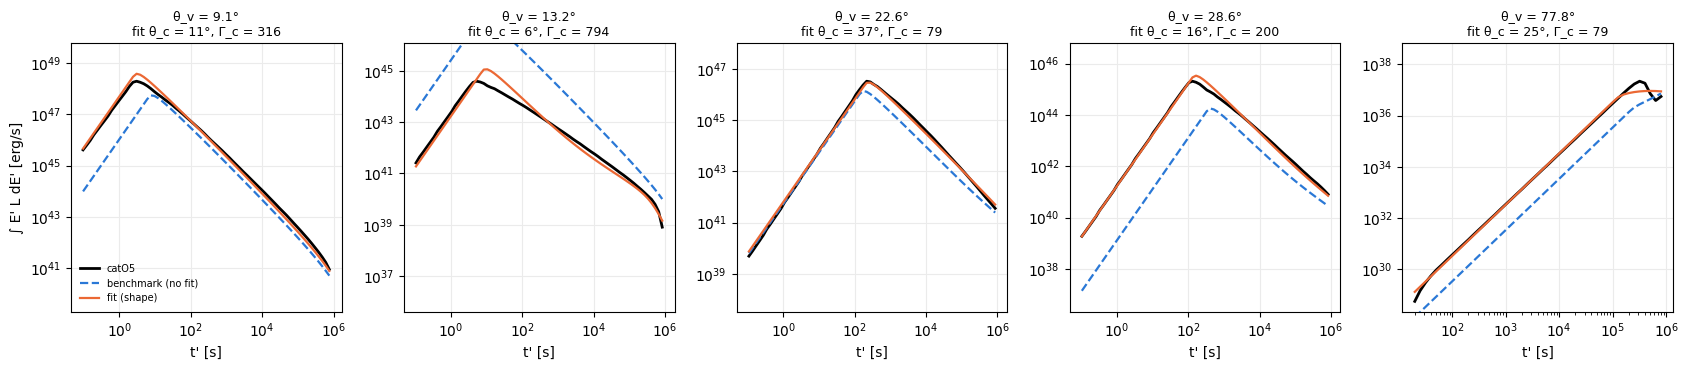

In [6]:
real = grb_model.GRBModelSet.from_inaf_dir(paths.GRB_MODEL_RAW_DIR)


def photon_index_of(m):   # the catO5 spectra are power laws; slope at the low-energy end
    j = m.time.size // 2
    return -np.polyfit(np.log(m.energy[:15]), np.log(m.L[:15, j]), 1)[0]


thc_grid = np.geomspace(4, 45, 13)
log_g_grid = np.arange(1.7, 2.95, 0.2)
rows = []
t0 = time.time()
for th in real.angles_deg:
    r = real.models[th]
    lr = np.log10(r.light_curve())
    base = replace(B, e_gamma_iso_erg=r.E_iso, photon_index=photon_index_of(r))
    m_base = ph.model_at_theta(base, th, energy_grid_GeV=r.energy, time_grid_s=r.time)
    row = dict(theta=th, r=r, base=base, m_base=m_base,
               rms_base=np.sqrt(np.mean((lr - np.log10(m_base.light_curve())) ** 2)))
    if FIT_CATO5:
        best = None
        for lg in log_g_grid:
            for thc in thc_grid:
                P = replace(base, theta_core_deg=thc, gamma_core=10 ** lg)
                rel = ph.offaxis_luminosity(P, th, r.time, n_psi=64)
                ok = rel > 0
                rms = np.std(lr[ok] - np.log10(rel[ok]))   # free amplitude: only the shape is fitted
                if best is None or rms < best[0]:
                    best = (rms, P)
        m_fit = ph.model_at_theta(best[1], th, energy_grid_GeV=r.energy, time_grid_s=r.time)
        row.update(rms_fit=best[0], P_fit=best[1], m_fit=m_fit,
                   amp=np.mean(lr - np.log10(m_fit.light_curve())))
    rows.append(row)
print(f"done in {time.time() - t0:.0f} s\n")

sigma_amp = np.hypot(ph.LX11H_SCATTER_DEX, ph.LTEV_LX_RATIO_LOG10_SCATTER)
print(f"{'file':>8} {'E_iso':>8} {'p':>5} | {'benchmark':>9} | {'fit: theta_core':>15} {'Gamma_core':>11} "
      f"{'shape rms':>9} {'amplitude':>9}")
for row in rows:
    s = (f"{row['theta']:7.2f}° {row['r'].E_iso:8.1e} {row['base'].photon_index:5.2f} | "
         f"{row['rms_base']:5.2f} dex |")
    if FIT_CATO5:
        P = row["P_fit"]
        z_th = (np.log10(P.theta_core_deg) - ph.LOG10_THETA_CORE_DEG_MEAN) / ph.LOG10_THETA_CORE_DEG_STD
        z_g = (np.log10(P.gamma_core) - ph.LOG10_GAMMA_CORE_MEAN) / ph.LOG10_GAMMA_CORE_STD
        s += (f" {P.theta_core_deg:6.1f}° ({z_th:+.1f}σ) {P.gamma_core:5.0f} ({z_g:+.1f}σ) "
              f"{row['rms_fit']:5.2f} dex {row['amp']:+5.2f} dex ({row['amp'] / sigma_amp:+.1f}σ)")
    print(s)
print("\nbenchmark = rms of log10 L, no free parameter. Fit = rms about a free amplitude; the amplitude is the")
print(f"offset from the recipe's 11 h anchor, in units of its own scatter ({sigma_amp:.2f} dex). "
      "The Gamma grid spans ±3σ.")

fig, axes = plt.subplots(1, 5, figsize=(17, 3.8))
for ax, row in zip(axes, rows):
    r = row["r"]
    ax.loglog(r.time, r.light_curve(), color="k", lw=2, label="catO5")
    ax.loglog(r.time, row["m_base"].light_curve(), color="#2a78d6", ls="--", lw=1.6, label="benchmark (no fit)")
    title = f"θ_v = {row['theta']:.1f}°"
    if FIT_CATO5:
        ax.loglog(r.time, row["m_fit"].light_curve() * 10 ** row["amp"], color="#eb6834", lw=1.6,
                  label="fit (shape)")
        title += f"\nfit θ_c = {row['P_fit'].theta_core_deg:.0f}°, Γ_c = {row['P_fit'].gamma_core:.0f}"
    ax.set_title(title, fontsize=9)
    ax.set_xlabel("t' [s]")
    ax.set_ylim(r.light_curve().max() * 1e-9, r.light_curve().max() * 30)
    ax.grid(True, which="major", color="0.92", lw=0.8)
axes[0].set_ylabel("∫ E' L dE' [erg/s]")
axes[0].legend(fontsize=7, frameon=False, loc="lower left")
fig.tight_layout()
plt.show()

**Reading.** With no free parameter, the benchmark is within 0.4–0.9 dex rms of three files (22.6°,
9.1°, 77.8°). The other two, 28.6° and 13.2°, are off by 1.5–1.8 dex, so their events must have had a
different core. Once $\theta_\mathrm{core}$ and $\Gamma_\mathrm{core}$ are fitted, four files match
in shape to 0.09–0.14 dex and the fifth (13.2°) to 0.25 dex. The fitted $\theta_\mathrm{core}$ (6°–37°)
are all within about 2σ of the population, and four of the five amplitudes are within 1σ of the
recipe's own scatter. The files look like ordinary draws from this recipe, run through this off-axis
method. Limits of the test:

- The fitted Γ span −2σ to +3σ, and the 13.2° one sits at the +3σ end of the grid. With a free
  amplitude, $\Gamma_\mathrm{core}$ and $\theta_\mathrm{core}$ partly trade off, so the fitted Γ are
  loosely constrained.
- The 77.8° file matches in shape (0.13 dex) but sits 2.0 dex below the recipe's anchor, 3.4σ of the
  recipe's own amplitude scatter. It is the one file whose flux comes entirely from late, mildly
  relativistic material, where the normalisation of each element is least certain (§8). Under the
  Step 6 normalisation to $L_k$ this amplitude does not reach the upper limit; the shape does, and
  it matches.

## 5. Putting the scatter back: systematics, or a fixed bank

The benchmark is a single jet. There are three ways to deal with the population around it, and
adding random noise to the flux is not one of them. After the Step 6 normalisation, any multiplicative
noise drops out, and noise on the shape has no physical meaning unless it comes from the recipe's own
distributions.

1. **Nominal: the benchmark, fixed.** One cache (§6), the same in every iteration. The limit reads
   "for the population's median short GRB".
2. **Systematics: one-sigma variants.** `one_sigma_variants(B)` moves one shape input at a time to its
   16th or 84th percentile. Rerunning the upper limit with the variant caches that matter gives a
   systematic band around the nominal limit.
3. **Marginalised: a fixed bank.** `draw_jet_params(rng, K)` draws K complete jets, once, with a fixed
   seed. Each gets its own cache, and iteration $i$ uses bank member $k_i$, drawn from the realisation's
   own seed. The pipeline already uses common random numbers (physics_and_methods §6.5), so $k_i$ must
   be drawn with them and the bisection steps see the same bank members. The limit is then
   marginalised over the population, like the sky position, distance and viewing angle already are.

Which inputs matter? Below, each variant is compared with the benchmark in a reference window, a
placeholder for the real GTIs. Two numbers are given per case:

- **the log-slope in the window.** This is the shape, which is what survives the $L_k$ normalisation
  when the exposure changes across the GTIs (pointings, zenith). If the exposure is uniform in time,
  even this drops out, and the photon index is the only input left.
- **the change in fluence.** This would matter only if the limit were placed on the model's own
  normalisation (e.g. $E_{\gamma,\mathrm{iso}}$) instead of on $L_k$.

40 variant models in 18 s

window t' = 1-5 h (rest frame)
theta_v         input |  window log-slope: -1σ  bench  +1σ |  d log10 fluence: -1σ   +1σ
     0°    theta_core |          -1.44  -1.43  -1.42       |           0.01  -0.01
     0°    gamma_core |          -1.41  -1.43  -1.43       |          -0.01   0.01
     0°   e_gamma_iso |          -1.45  -1.43  -1.41       |          -1.44   0.84
     0°         beta2 |          -1.87  -1.43  -0.97       |           0.34  -0.33
     0°  photon_index |          -1.42  -1.43  -1.43       |          -0.00   0.00

    20°    theta_core |          -1.11  -1.39  -1.41       |          -1.29   0.54
    20°    gamma_core |          -1.36  -1.39  -1.40       |          -0.02   0.02
    20°   e_gamma_iso |          -1.40  -1.39  -1.37       |          -1.41   0.83
    20°         beta2 |          -1.80  -1.39  -0.95       |           0.30  -0.30
    20°  photon_index |          -1.38  -1.39  -1.39       |          -0.00   0.00

    30°    theta_core

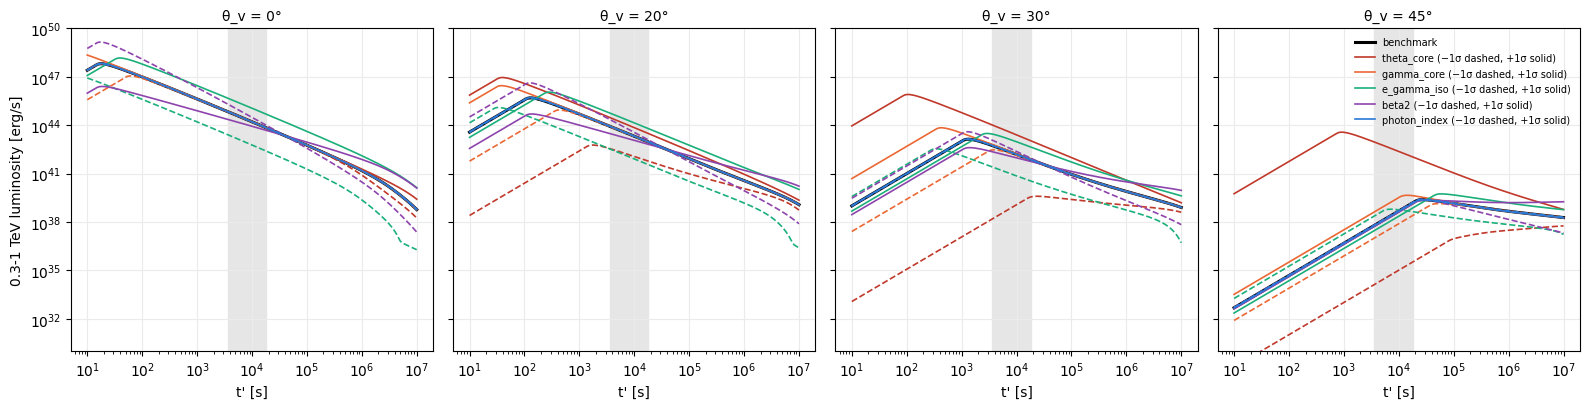

In [7]:
REF_WINDOW_S = (3600.0, 5 * 3600.0)   # rest frame; a placeholder for the real GTIs
THETA_SHOW = [0.0, 20.0, 30.0, 45.0]
variants = ph.one_sigma_variants(B)
t_w = np.geomspace(*REF_WINDOW_S, 60)
t_lc = np.geomspace(10, 1e7, 200)


def window_metrics(P, th):
    m = ph.model_at_theta(P, th, time_grid_s=t_lc)
    L_w = vhe_lum(m, t_w)
    slope = np.log(L_w[-1] / L_w[0]) / np.log(t_w[-1] / t_w[0])
    return np.log10(np.trapezoid(L_w, t_w)), slope, vhe_lum(m, t_lc)


t0 = time.time()
metrics = {th: {"benchmark": window_metrics(B, th)} for th in THETA_SHOW}
for name, (lo, hi) in variants.items():
    for th in THETA_SHOW:
        metrics[th][name] = (window_metrics(lo, th), window_metrics(hi, th))
print(f"{len(variants) * 2 * len(THETA_SHOW)} variant models in {time.time() - t0:.0f} s\n")

print(f"window t' = {REF_WINDOW_S[0] / 3600:g}-{REF_WINDOW_S[1] / 3600:g} h (rest frame)")
print(f"{'theta_v':>7} {'input':>13} | {'window log-slope: -1σ  bench  +1σ':>34} | {'d log10 fluence: -1σ   +1σ':>27}")
for th in THETA_SHOW:
    f0, s0, _ = metrics[th]["benchmark"]
    for name in variants:
        (f_lo, s_lo, _), (f_hi, s_hi, _) = metrics[th][name]
        print(f"{th:6.0f}° {name:>13} | {s_lo:14.2f} {s0:6.2f} {s_hi:6.2f}       | {f_lo - f0:14.2f} {f_hi - f0:6.2f}")
    print()

colors = {"theta_core": "#c0392b", "gamma_core": "#eb6834", "e_gamma_iso": "#1baf7a",
          "beta2": "#8e44ad", "photon_index": "#2a78d6"}
fig, axes = plt.subplots(1, len(THETA_SHOW), figsize=(16, 4.2), sharey=True)
for ax, th in zip(axes, THETA_SHOW):
    ax.loglog(t_lc, metrics[th]["benchmark"][2], color="k", lw=2.2, label="benchmark")
    for name, color in colors.items():
        (_, _, L_lo), (_, _, L_hi) = metrics[th][name]
        ax.loglog(t_lc, L_lo, color=color, lw=1.2, ls="--")
        ax.loglog(t_lc, L_hi, color=color, lw=1.2, label=f"{name} (−1σ dashed, +1σ solid)")
    ax.axvspan(*REF_WINDOW_S, color="0.9", zorder=0)
    ax.set_title(f"θ_v = {th:g}°", fontsize=10)
    ax.set_xlabel("t' [s]")
    ax.set_ylim(1e30, 1e50)
    ax.grid(True, which="major", color="0.92", lw=0.8)
axes[0].set_ylabel("0.3-1 TeV luminosity [erg/s]")
axes[-1].legend(fontsize=7, frameon=False, loc="upper right")
fig.tight_layout()
plt.show()

**Reading.**

- **On-axis**, $\beta_2$ is the only input that changes the shape in the window (log-slope −1.87 to
  −0.97). $E_{\gamma,\mathrm{iso}}$ moves the fluence (−1.4/+0.8 dex), but only as an amplitude,
  through the 11 h anchor.
- **Off-axis, $\theta_\mathrm{core}$ dominates.** It sets $\theta_v/\theta_\mathrm{core}$, which Abe et
  al. single out as the main driver of detectability. At 30° its −1σ variant turns the decaying
  light curve into a rising one; at 45° its +1σ variant does the opposite. The fluence moves by 3–4 dex.
- **$\Gamma_\mathrm{core}$** does nothing on-axis but matters more with angle (±0.7 dex and a different
  slope at 45°), because the off-axis flux comes from the wings, whose Lorentz factor it sets.
- **$E_{\gamma,\mathrm{iso}}$** changes the shape only through the time scale $t\propto E^{1/3}$ (as would
  $n$, through $(E/n)^{1/3}$). That matters mainly where the window sits near the peak, as at 45°.
- **The photon index** leaves the light curve unchanged. It is still the one input that changes the
  spectrum, and so the counts through the IRF.

**Recommendation.** Use the benchmark for the nominal limit. For the systematic band, rerun first with
the two $\theta_\mathrm{core}$ variants: they dominate at every off-axis angle, and 84% of S240615dg's
draws lie beyond 12°. Add $\Gamma_\mathrm{core}$, $\beta_2$ and the photon index if the band should
be complete (`SAVE_VARIANTS = True` writes all ten caches). Build a bank only if a limit marginalised
over the population is wanted. The next cell shows what that means at 30°: the population is much
wider than any single variant.

30 bank members at theta_v = 30 deg in 18 s
window log-slope     16/50/84%: [-1.55 -0.95  1.83]   (benchmark -1.26)
d log10 fluence      16/50/84%: [-2.96 -1.19  0.68]


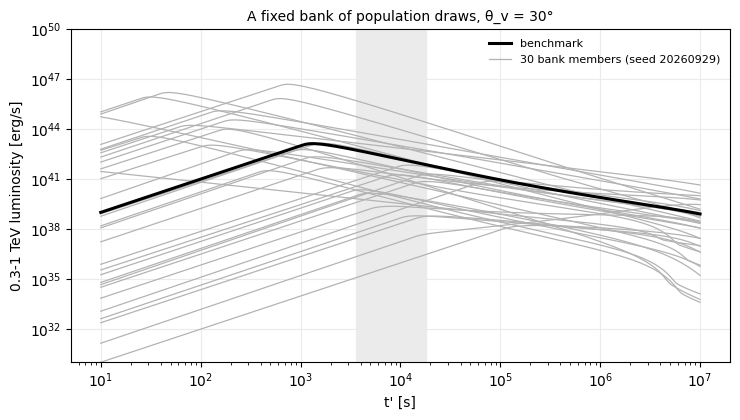

In [8]:
K_DEMO, THETA_DEMO = 30, 30.0
bank = ph.draw_jet_params(np.random.default_rng(20260929), K_DEMO)
t0 = time.time()
bank_metrics = [window_metrics(P, THETA_DEMO) for P in bank]
print(f"{K_DEMO} bank members at theta_v = {THETA_DEMO:g} deg in {time.time() - t0:.0f} s")
f0, s0, L0 = metrics[THETA_DEMO]["benchmark"]
slopes = np.array([m[1] for m in bank_metrics])
dflu = np.array([m[0] for m in bank_metrics]) - f0
print(f"window log-slope     16/50/84%: {np.percentile(slopes, [16, 50, 84]).round(2)}   (benchmark {s0:.2f})")
print(f"d log10 fluence      16/50/84%: {np.percentile(dflu, [16, 50, 84]).round(2)}")

fig, ax = plt.subplots(figsize=(7.5, 4.3))
for P, m in zip(bank, bank_metrics):
    ax.loglog(t_lc, m[2], color="0.7", lw=0.9)
ax.loglog(t_lc, L0, color="k", lw=2.2, label="benchmark")
ax.plot([], [], color="0.7", lw=0.9, label=f"{K_DEMO} bank members (seed 20260929)")
ax.axvspan(*REF_WINDOW_S, color="0.92", zorder=0)
ax.set_ylim(1e30, 1e50)
ax.set_xlabel("t' [s]"); ax.set_ylabel("0.3-1 TeV luminosity [erg/s]")
ax.set_title(f"A fixed bank of population draws, θ_v = {THETA_DEMO:g}°", fontsize=10)
ax.grid(True, which="major", color="0.92", lw=0.8)
ax.legend(fontsize=8, frameon=False, loc="upper right")
fig.tight_layout()
plt.show()

## 6. Saving the cache

One directory per jet under `data/models/grb_afterglow_phenomenological/`, one `.npz` per angle,
written by `GRBModelSet.save` (the same format as the catO5 cache). The directory is cleared first so
that no stale angle survives a change of grid. Unlike the catO5 set, every angle here belongs to the same
jet, so no common-$E_\mathrm{iso}$ rescaling is needed after loading.

The checks after saving: the reload is exact; `get_model(θ, "interp", align_peaks=False)` at angles
between grid nodes against a direct build; and $E_{\gamma,\mathrm{iso}}$. On a 1° grid neighbouring
light curves are close enough that the plain fixed-$t'$ blend cannot double-peak. The peak-aligned
default is no more accurate here, and past 57° it warns on every call because the peak lies beyond the
time grid. For this model, changing $E_{\gamma,\mathrm{iso}}$
is an exact rescaling: times scale as $E^{1/3}$, and luminosities as $E^{0.83+\beta_2/3}$ (the Berger slope,
plus the shift of the fixed 11 h anchor along the decay). So a cache can be moved to another
$E_{\gamma,\mathrm{iso}}$ with `rescaled_to_eiso` instead of being rebuilt.

In [9]:
def save_set(model_set, name):
    out = paths.GRB_MODEL_PHENOMENOLOGICAL_DIR / name
    out.mkdir(parents=True, exist_ok=True)
    for f in out.glob("*.npz"):
        f.unlink()
    model_set.save(out)
    return out


out = save_set(bench, "benchmark")
reloaded = grb_model.GRBModelSet.load(out)
assert np.array_equal(reloaded.angles_deg, bench.angles_deg)
assert all(np.array_equal(reloaded.models[th].L, bench.models[th].L) for th in bench.angles_deg)
print(f"benchmark: {len(reloaded.models)} angles written to {out}")

if SAVE_VARIANTS:
    t0 = time.time()
    for name, (lo, hi) in variants.items():
        for tag, P in [("lo", lo), ("hi", hi)]:
            save_set(ph.model_set(P), f"{name}_{tag}")
    print(f"ten variant caches written in {time.time() - t0:.0f} s")

E_q, t_q = np.geomspace(2, 5e3, 20), np.geomspace(1, 1e6, 60)
theta_off = np.arange(0.5, 90, 3.7)   # 25 angles between grid nodes
err = [np.max(np.abs(np.log10(reloaded.get_model(th, method="interp", align_peaks=False).at(E_q, t_q)
                              / ph.model_at_theta(B, th).at(E_q, t_q)))) for th in theta_off]
print(f"\ninterp (align_peaks=False) vs direct build, {theta_off.size} off-grid angles: "
      f"median |d log10 L| = {np.median(err):.4f}, max = {max(err):.4f} at {theta_off[np.argmax(err)]:.1f} deg")

print(f"\n{'k = E/E_bench':>13} {'theta_v':>8} {'rescaled vs rebuilt, max |d log10 L|':>38}")
for k in [0.1, 10.0]:
    for th in [0.0, 30.0]:
        rebuilt = ph.model_at_theta(replace(B, e_gamma_iso_erg=B.e_gamma_iso_erg * k), th)
        resc = reloaded.models[th].rescaled_to_eiso(B.e_gamma_iso_erg * k,
                                                    L_exponent=ph.LX11H_SLOPE + B.beta2 / 3, t_exponent=1 / 3)
        tt = t_q[(t_q > resc.time[0]) & (t_q < resc.time[-1])]
        print(f"{k:13g} {th:8.0f} {np.max(np.abs(np.log10(rebuilt.at(E_q, tt) / resc.at(E_q, tt)))):38.4f}")

benchmark: 91 angles written to /home/jjimenezq/projects/gw/gw-gamma-global-uls/data/models/grb_afterglow_phenomenological/benchmark

interp (align_peaks=False) vs direct build, 25 off-grid angles: median |d log10 L| = 0.0053, max = 0.0448 at 85.6 deg

k = E/E_bench  theta_v   rescaled vs rebuilt, max |d log10 L|
          0.1        0                                 0.0050
          0.1       30                                 0.0091
           10        0                                 0.0024
           10       30                                 0.0032


## 7. How `sim_3d` uses it

```python
from gwuls import grb_model, paths

model_set = grb_model.GRBModelSet.load(paths.GRB_MODEL_PHENOMENOLOGICAL_DIR / "benchmark")

# per iteration i, after d_i, z_i and theta_i have been drawn (Step 4):
model_i = model_set.get_model(theta_i, method="interp", align_peaks=False)   # 1° grid: <= 0.05 dex
# Step 6: normalise model_i to L_k over the GTIs.  Step 7:
E_obs, t_obs, F_i = model_i.to_observer(d_i, z_i, energy_obs=E_grid, time_obs=t_grid, apply_ebl=True)
```

- **Systematics:** the same code with `"theta_core_lo"`, `"theta_core_hi"`, … in place of
  `"benchmark"` (written with `SAVE_VARIANTS = True`).
- **Bank:** one cache per member, e.g. `bank_000/` … `bank_049/`, built with
  `save_set(ph.model_set(P), f"bank_{k:03d}")` for `P in draw_jet_params(np.random.default_rng(SEED), K)`.
  Iteration $i$ loads member `k_i = rng_i.integers(K)`, with `rng_i` the realisation's own seeded
  generator, so every bisection step reuses the same member. A full cache takes about a minute per
  member.
- **Anything else** (a jet from a fit, a different density): `ph.model_set(replace(ph.BENCHMARK, ...))`.

## 8. Caveats

- **On-axis, the peak is smoothed** by the arrival-time spread across the beaming cone (§2.1). After the
  11 h renormalisation the decay matches the recipe exactly, while the rise and the peak are lower than
  the recipe's sharp broken power law (the rise by a factor of about 4). For any follow-up that
  starts after about a minute, on-axis observations sit in the decay.
- **The element normalisation** $d\Omega/\Omega_\mathrm{beam}(\Gamma)$ is the standard point-source
  choice, and it makes a uniform shell reproduce itself exactly. Lamb & Kobayashi's exact convention
  is not spelled out in either source. The two can differ most for late, mildly relativistic
  material, which is where the 77.8° catO5 file disagrees in amplitude (§4).
- **Dynamics are simple:** Blandford–McKee deceleration from $t_\mathrm{dec}$, with no lateral spreading,
  no transition to the non-relativistic regime (Γ is only floored at 1) and no counter-jet. The jet is
  truncated at $\theta_\mathrm{max}$ ($\Gamma_0=5$), as in Abe et al. Far off-axis at $t'\gtrsim10^6$ s,
  these simplifications matter.
- **$t_\mathrm{dec}$ uses the isotropic-equivalent energy** (§2). This differs from `sample_events` in the
  stochastic notebook, which uses the collimated energy (about 5× earlier $t_\mathrm{dec}$).
- **Band of the anchor.** $L_\mathrm{TeV,11h}$ is the 0.3–1 TeV luminosity (Abe et al. Sec. 3.3), and
  `model_at_theta` normalises that band. `_build_grb_model` (stochastic notebook) normalises the full
  1 GeV–10 TeV grid to it instead, which for $p=2.2$ makes its 0.3–1 TeV luminosity 12× lower. Under
  the $L_k$ normalisation neither choice reaches the upper limit.
- **The photon index is constant** in time and angle, as in the recipe and in the catO5 files (fitted
  $p$ = 2.07–2.23, with no trend in angle). The model therefore has no angle-dependent spectral softening.
- **Inherited from the stochastic module:** the Eq. 1 vs Eq. 2 width convention of `jet_structure`,
  the $t_\mathrm{dec}$ prefactor $R_\mathrm{dec}/(2c\Gamma_0^2)$, and 11 h read as a rest-frame time.
  See §5 of the stochastic notebook.
- **The reference window of §5 is a placeholder.** Which inputs reach the limit depends on how the
  exposure changes across the real GTIs. The ranking should be redone with them once Step 6 is in
  `sim_3d`.